### Grid usage

This notebook quickly goes through the basic usage of the Grid classes.
There is an integer grid that basically represents combinations of integers and knows which formal coordinate it
corresponds to. Then, there is a float-grid that knows how to translate the integer points to floats. The code has been adapted from the `pyQuTree` package written by Roman Ellerbrock.

In [1]:
import numpy as np

from tq_mtopt.grid import Grid

# create a 1D grid
grid_1d = Grid(range(10), coords=0)
print("1D grid:\n", grid_1d)

# manually create two 2D grids
grid_1 = Grid(np.array([[0, 1], [1, 2], [2, 3]]), coords=[2, 1])

grid_2 = Grid(np.array([[4, 5], [5, 6], [6, 7]]), coords=[3, 0])

print("2D grid 1:\n", grid_1)
print("2D grid 2:\n", grid_2)

1D grid:
 coords: [0]
grid:
[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]
2D grid 1:
 coords: [2 1]
grid:
[[0 1]
 [1 2]
 [2 3]]
2D grid 2:
 coords: [3 0]
grid:
[[4 5]
 [5 6]
 [6 7]]


In [2]:
# Cartesian product of the two 2D grids:
# combine the two 2D grids into a 4D grid
grid_12 = grid_1 @ grid_2
print("4D grid (unsorted coords):\n", grid_12)

# the coordinates may be out of order, let's resort them
grid_12 = grid_12.permute()
print("4D grid after permute():\n", grid_12)

# ... and back again (permute() applies the inverse permutation now)
grid_12 = grid_12.permute()
print("4D grid after permute() again (back to original order):\n", grid_12)

4D grid (unsorted coords):
 coords: [2 1 3 0]
grid:
[[0 1 4 5]
 [0 1 5 6]
 [0 1 6 7]
 [1 2 4 5]
 [1 2 5 6]
 [1 2 6 7]
 [2 3 4 5]
 [2 3 5 6]
 [2 3 6 7]]
4D grid after permute():
 coords: [0 1 2 3]
grid:
[[5 1 0 4]
 [6 1 0 5]
 [7 1 0 6]
 [5 2 1 4]
 [6 2 1 5]
 [7 2 1 6]
 [5 3 2 4]
 [6 3 2 5]
 [7 3 2 6]]
4D grid after permute() again (back to original order):
 coords: [2 1 3 0]
grid:
[[0 1 4 5]
 [0 1 5 6]
 [0 1 6 7]
 [1 2 4 5]
 [1 2 5 6]
 [1 2 6 7]
 [2 3 4 5]
 [2 3 5 6]
 [2 3 6 7]]


In [3]:
from tq_mtopt.grid import cartesian_product

# more complex combination of multiple grids
grid_1 = Grid(np.array([[0, 1], [1, 2], [2, 3]]), coords=[2, 1])

grid_2 = Grid(np.array([[4, 5], [5, 6], [6, 7]]), coords=[3, 0])

grid_3 = Grid(np.array([[8, 9], [9, 10], [10, 11]]), coords=[4, 5])

grids = [grid_1, grid_2, grid_3]

# combine the three 2D grids into a 6D grid
grid_123 = cartesian_product(grids)
print("grid_123 shape:", grid_123.grid.shape)

# too many grid points... get a random selection of 10 high-dimensional points
print("Random subset of 10 points:\n", grid_123.random_subset(10))

grid_123 shape: (27, 6)
Random subset of 10 points:
 coords: [2 1 3 0 4 5]
grid:
[[ 2  3  4  5 10 11]
 [ 2  3  6  7 10 11]
 [ 2  3  4  5  9 10]
 [ 1  2  6  7 10 11]
 [ 2  3  6  7  8  9]
 [ 1  2  5  6  9 10]
 [ 1  2  4  5  8  9]
 [ 0  1  6  7 10 11]
 [ 0  1  5  6 10 11]
 [ 2  3  5  6  8  9]]


In [4]:
# Now to float grids!
# something like [0.1, 0.2, ...]

# just needs a generator and a coordinate
f_grid_1 = Grid(np.linspace(0.0, 1.0, 10), coords=0)
f_grid_2 = Grid(np.linspace(-1.0, 1.0, 15), coords=1)

# combine
subgrid = (f_grid_1 @ f_grid_2).random_subset(10)
print("Subgrid:\n", subgrid)

# How can we evaluate a function on this grid?
# Function that evaluates a grid point (e.g., objective in optimization)
fun = lambda x: np.sum(x**2)

print("Function values on subgrid:\n", subgrid.evaluate(fun))

Subgrid:
 coords: [0 1]
grid:
[[ 0.77777778  0.57142857]
 [ 0.33333333 -0.42857143]
 [ 0.66666667  0.42857143]
 [ 0.77777778 -0.28571429]
 [ 0.         -0.42857143]
 [ 1.         -0.71428571]
 [ 0.33333333  0.85714286]
 [ 0.44444444  0.85714286]
 [ 1.          0.71428571]
 [ 0.88888889 -0.71428571]]
Function values on subgrid:
 [0.93146888 0.29478458 0.62811791 0.68657092 0.18367347 1.51020408
 0.84580499 0.93222474 1.51020408 1.30032754]


In [5]:
fun = lambda x: np.sum(x**2)

grid_1 = Grid(np.linspace(0.0, 1.0, 5), coords=0)
grid_2 = Grid(np.linspace(0.0, 1.0, 5), coords=1)

grid_12 = grid_1 @ grid_2
grid_12 = grid_12.random_subset(10)

f_grid = grid_12.evaluate(fun)
print(f_grid)

[0.625  0.25   1.     0.0625 0.3125 1.25   0.0625 0.3125 2.     1.25  ]


In [6]:
# Number of points in each 1D primitive grid
num_points = 10

# (Optional) target TT rank, typically used elsewhere;
# included here only as a placeholder for later examples.
rank = 2

# --------------------------------------------------------------------
# 1. Build primitive 1D grids for three coordinates q0, q1, q2
#    Each grid spans [0, 1] with `num_points` equally spaced points.
# --------------------------------------------------------------------
primitive_grids = [Grid(np.linspace(0.0, 1.0, num_points), coords=i) for i in range(3)]

# `primitive_grids[0]` : coordinate 0
# `primitive_grids[1]` : coordinate 1
# `primitive_grids[2]` : coordinate 2

# --------------------------------------------------------------------
# 2. Form a 2D grid over coordinates (0, 1) and randomly subsample it
# --------------------------------------------------------------------
xy_grid = (primitive_grids[0] @ primitive_grids[1]).random_subset(10)

# `xy_grid` now represents up to 10 points in the 2D space (q0, q1).

# --------------------------------------------------------------------
# 3. Combine that 2D grid with the 1D grid over coordinate 2
#    to obtain a 3D grid over coordinates (0, 1, 2),
#    and then take a random subset of 10 points.
# --------------------------------------------------------------------
z_grid = primitive_grids[2]

xyz_grid_subset = (xy_grid @ z_grid).random_subset(10)

print("Random subset of 3D grid points (q0, q1, q2):")
print(xyz_grid_subset)

Random subset of 3D grid points (q0, q1, q2):
coords: [0 1 2]
grid:
[[0.77777778 0.88888889 0.44444444]
 [0.33333333 1.         0.77777778]
 [0.55555556 0.11111111 0.44444444]
 [0.33333333 1.         0.33333333]
 [0.66666667 0.55555556 0.55555556]
 [0.77777778 0.88888889 0.11111111]
 [0.77777778 1.         1.        ]
 [0.11111111 0.66666667 0.22222222]
 [0.11111111 0.66666667 0.44444444]
 [0.11111111 0.55555556 0.33333333]]


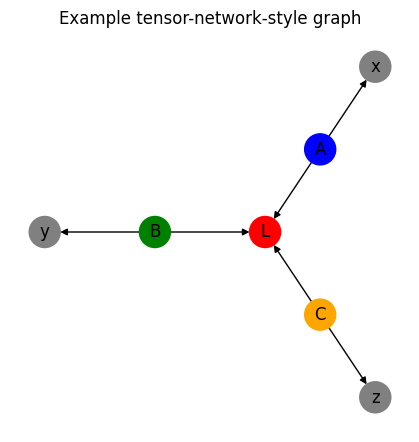

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout

# --------------------------------------------------------------------
# 1. Build a small directed graph
#
#   A, B, C  ---->  L
#    |   |          ^
#    v   v          |
#    x   y   z  ----
#
# Core nodes: 1 (A), 2 (B), 3 (C), 0 (L)
# Leaf / observable nodes: 11 (x), 12 (y), 13 (z)
# --------------------------------------------------------------------
graph = nx.DiGraph()
graph.add_edges_from(
    [
        (1, 11),  # A -> x
        (2, 12),  # B -> y
        (3, 13),  # C -> z
        (1, 0),  # A -> L
        (2, 0),  # B -> L
        (3, 0),  # C -> L
    ]
)

# --------------------------------------------------------------------
# 2. Compute a nice radial layout using Graphviz
#    (requires 'graphviz' and 'pydot' installed in the environment).
# --------------------------------------------------------------------
pos = graphviz_layout(graph, prog="twopi")

# --------------------------------------------------------------------
# 3. Define labels and colors for visualization
# --------------------------------------------------------------------
labels = {
    11: "x",
    12: "y",
    13: "z",
    0: "L",
    1: "A",
    2: "B",
    3: "C",
}

node_colors = {
    11: "grey",
    12: "grey",
    13: "grey",
    0: "red",  # e.g. logical / output node
    1: "blue",
    2: "green",
    3: "orange",
}

# --------------------------------------------------------------------
# 4. Draw the graph
# --------------------------------------------------------------------
plt.figure(figsize=(4, 4))
nx.draw(
    graph,
    pos=pos,
    with_labels=True,
    labels=labels,
    node_color=[node_colors[n] for n in graph.nodes],
    node_size=500,
    arrows=True,
)
plt.title("Example tensor-network-style graph")
plt.axis("off")
plt.show()

In [8]:
from tq_mtopt.grid import Grid
from tq_mtopt.plot import plot_xyz

# ------------------------------------------------------------------------
# Example: simple 3D tree-like combination of grids
#
# Conceptual TN structure:  {{{x}, {y}}, {z}}
# where x, y, z are three 1D coordinates in [0, 1].
# We:
#   1. Build primitive 1D grids for x, y, z.
#   2. Construct "up-sweep" and "down-sweep" edge grids via random subsets
#      and Cartesian products.
#   3. Build node grids A, B, C, L as combinations of primitive and edge grids.
#   4. Form a single combined Grid xyz = L + A + B + C and evaluate fun on it.
#   5. Visualize the result with plot_xyz.
# ------------------------------------------------------------------------

# Primitive grid parameters
num_points = 15  # number of points per 1D primitive grid
rank = 3  # effective rank / subset size used in this toy example

# Coordinates indices
x_coord, y_coord, z_coord = 0, 1, 2

# 1. Build primitive 1D grids for x, y, z
primitive_grids = [
    Grid(np.linspace(0.0, 1.0, num_points), coords=i)
    for i in (x_coord, y_coord, z_coord)
]

grid_x = primitive_grids[x_coord]
grid_y = primitive_grids[y_coord]
grid_z = primitive_grids[z_coord]

# ------------------------------------------------------------------------
# 2. Build incomplete edge grids via an "up-sweep" and "down-sweep"
#
# Up-sweep:
#   a_up : subset on x
#   b_up : subset on y
#   c_up : subset on (x, y)
#
# Down-sweep:
#   c_down : subset on z
#   a_down : subset on (z, y)
#   b_down : subset on (z, x)
# ------------------------------------------------------------------------

# Up-sweep
a_up = grid_x.random_subset(rank)  # edge towards x
b_up = grid_y.random_subset(rank)  # edge towards y
c_up = (a_up @ b_up).random_subset(rank)  # edge towards (x, y)

# Down-sweep
c_down = grid_z.random_subset(rank)  # edge towards z
a_down = (c_down @ b_up).random_subset(rank)  # edge towards (z, y)
b_down = (c_down @ a_up).random_subset(rank)  # edge towards (z, x)

# ------------------------------------------------------------------------
# 3. Build complete node grids
#
# A : node attached to x and (z, y)
# B : node attached to y and (z, x)
# C : node attached to z and (x, y)
# L : "logical" / root node over (x, y, z)
#
# We permute after each combination to restore sorted coordinate order.
# ------------------------------------------------------------------------

grid_A = (grid_x @ a_down).permute()
grid_B = (grid_y @ b_down).permute()
grid_C = (grid_z @ c_up).permute()
grid_L = (a_up @ b_up @ c_down).permute()

# ------------------------------------------------------------------------
# 4. Combine node grids into a single Grid and evaluate the objective
#
# '+' is the direct sum of grids with identical coords, so
# xyz contains all points from L, A, B, C stacked row-wise.
# ------------------------------------------------------------------------

xyz_grid = grid_L + grid_A + grid_B + grid_C

# fun should be defined elsewhere, e.g.:
# fun = lambda x: np.sum(x**2)
values = xyz_grid.evaluate(fun)

# ------------------------------------------------------------------------
# 5. Visualize in 3D
#
# xyz_grid has three coordinates (x, y, z), so we can use plot_xyz.
# ------------------------------------------------------------------------

fig = plot_xyz(xyz_grid, values)
fig.show()

In [ ]:
# ------------------------------------------------------------------------
# Color-coding grid points by the node they originate from
#
# We have four node grids:
#   grid_A, grid_B, grid_C, grid_L
# and we want to visualize all their points in a single 3D plot,
# using a different color for each node:
#   A -> blue, B -> green, C -> orange, L -> red.
#
# Note: here we use categorical colors (strings) instead of numeric
# values. The `plot_xyz` helper will pass these directly to Plotly as
# marker colors.
# ------------------------------------------------------------------------

# Number of points in each node grid
num_A = grid_A.num_points()
num_B = grid_B.num_points()
num_C = grid_C.num_points()
num_L = grid_L.num_points()

# Build per-node color arrays
colors_A = ["blue"] * num_A
colors_B = ["green"] * num_B
colors_C = ["orange"] * num_C
colors_L = ["red"] * num_L

# Combine all node grids row-wise into a single Grid
combined_grid = grid_A + grid_B + grid_C + grid_L

# Concatenate colors in the same order
colors = np.array(colors_A + colors_B + colors_C + colors_L)

# Plot: each point is colored by its node of origin
fig = plot_xyz(combined_grid, colors)
fig.show()

In [10]:
# ------------------------------------------------------------------------
# Slicing a Grid
#
# Grids support NumPy-like 2D indexing:
#   grid[rows, cols]
#
# where:
#   - rows selects a subset of points,
#   - cols selects a subset of coordinates (dimensions).
#
# Here we:
#   * take the first 5 points (rows 0–4),
#   * restrict to the first two coordinates (cols 0 and 1),
#   and obtain a new Grid with shape (5, 2).
# ------------------------------------------------------------------------

grid = grid_A  # any Grid instance

# Slice: first 5 points, first 2 dimensions
subgrid = grid[:5, 0:2]

print("Sliced subgrid (first 5 points, first 2 dimensions):")
print(subgrid)

Sliced subgrid (first 5 points, first 2 dimensions):
coords: [0 1]
grid:
[[0.         0.92857143]
 [0.         0.28571429]
 [0.         0.28571429]
 [0.07142857 0.92857143]
 [0.07142857 0.28571429]]


Tensor-train nodes (with attributes):
[(0, {'grid': Grid(shape=(80, 3), coords=[0 1 2])}), (1, {'grid': Grid(shape=(320, 3), coords=[0 1 2])}), (2, {'grid': Grid(shape=(80, 3), coords=[0 1 2])}), (-1, {}), (-2, {}), (-3, {})]

Tensor-train edges (with attributes):
[(0, -1, {'coordinate': 0, 'r': 20}), (0, 1, {'r': 4, 'grid': Grid(shape=(4, 1), coords=[0])}), (1, -2, {'coordinate': 1, 'r': 20}), (1, 2, {'r': 4, 'grid': Grid(shape=(4, 2), coords=[1 0])}), (1, 0, {'r': 4, 'grid': Grid(shape=(4, 2), coords=[1 2])}), (2, -3, {'coordinate': 2, 'r': 20}), (2, 1, {'r': 4, 'grid': Grid(shape=(4, 1), coords=[2])}), (-1, 0, {'coordinate': 0, 'r': 20, 'grid': Grid(shape=(20, 1), coords=[0])}), (-2, 1, {'coordinate': 1, 'r': 20, 'grid': Grid(shape=(20, 1), coords=[1])}), (-3, 2, {'coordinate': 2, 'r': 20, 'grid': Grid(shape=(20, 1), coords=[2])})]


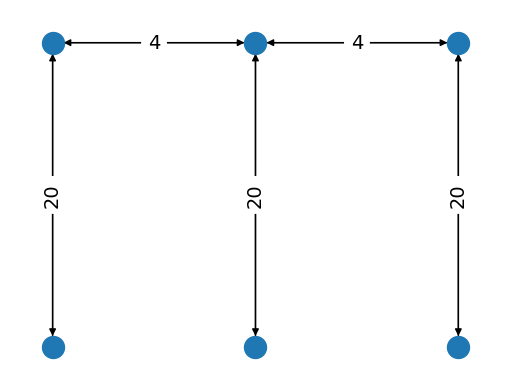

In [11]:
from tq_mtopt.network import tensor_train_graph
from tq_mtopt.grid import tensor_network_grid
from tq_mtopt.plot import plot_tensor_train_diagram, plot_tensor_network_xyz

# ------------------------------------------------------------------------
# Tensor-train example with attached grids
#
# We:
#   1. Build a tensor-train graph with `num_cores` cores and bond dimension
#      `rank`.
#   2. Attach 1D primitive grids to each coordinate and construct
#      edge/node grids via `tn_grid`.
#   3. Inspect the resulting graph structure (nodes/edges and attributes).
#   4. Visualize:
#        * the TT topology with `plot_tt_diagram`,
#        * the node grids in 3D with `plot_tn_xyz(fun)`.
# ------------------------------------------------------------------------

num_cores = 3  # number of TT cores (dimensions)
rank = 4  # TT bond dimension (edge rank)
num_primitive_points = 20  # number of points per 1D primitive grid

# 1. Build the tensor-train graph (no grids yet, just topology + ranks)
tensor_network = tensor_train_graph(
    num_cores=num_cores,
    rank=rank,
    primitive_grid=num_primitive_points,
)

# 2. Construct primitive 1D grids and attach them to the network
primitive_grids = [
    np.linspace(0.0, 1.0, num_primitive_points) for _ in range(num_cores)
]

tensor_network = tensor_network_grid(tensor_network, primitive_grids)

# 3. Inspect graph structure
print("Tensor-train nodes (with attributes):")
print(list(tensor_network.nodes(data=True)))

print("\nTensor-train edges (with attributes):")
print(list(tensor_network.edges(data=True)))

# 4a. Plot the TT diagram (1D topology with edge ranks)
fig_tt = plot_tensor_train_diagram(tensor_network)
plt.show()

# 4b. Plot the node grids in 3D, colored by fun(x) (defined earlier)
fig_xyz = plot_tensor_network_xyz(tensor_network, fun)
fig_xyz.show()

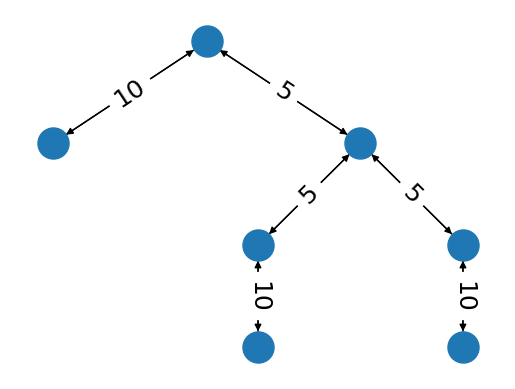

In [12]:
from tq_mtopt.network import balanced_tree
from tq_mtopt.grid import tensor_network_grid
from tq_mtopt.plot import plot_tree, plot_tensor_network_xyz

# ------------------------------------------------------------------------
# Balanced tree tensor network with grids
#
# We:
#   1. Build a (close-to) balanced tree TN over `num_dims` leaves.
#   2. Attach 1D primitive grids to each coordinate via `tn_grid`.
#   3. Visualize:
#        * the tree topology with edge ranks using `plot_tree`,
#        * the node grids in 3D using `plot_tn_xyz`.
#
# The structure here is different from a TT: internal nodes form a tree
# (binary-like), which is useful for higher-dimensional functions and
# hierarchical decompositions.
# ------------------------------------------------------------------------

num_dims = 3  # number of physical dimensions / leaves
num_primitive_points = 10  # number of points per 1D primitive grid
rank = 5  # internal bond dimension

# 1. Build a balanced tree tensor network
tree_network = balanced_tree(
    num_leaves=num_dims,
    rank=rank,
    phys_dim=num_primitive_points,
)

# 2. Construct primitive grids for each coordinate and attach them
primitive_grids = [np.linspace(0.0, 1.0, num_primitive_points) for _ in range(num_dims)]

tree_network = tensor_network_grid(tree_network, primitive_grids)

# 3a. Plot the tree structure with edge ranks
plot_tree(tree_network)
plt.show()

# 3b. Plot node grids in 3D, colored by fun(x) (defined earlier)
fig_xyz = plot_tensor_network_xyz(tree_network, fun)
fig_xyz.show()